In [142]:
import numpy as np
import matplotlib.pyplot as plt

In [180]:
def forward_modeller(theta, N_samples=10):
    modelled_data = theta[0] + theta[1] * np.arange(N_samples)
    return modelled_data

def residual(true_data,modelled_data):
    return true_data - modelled_data

def log_likelihood(r, sigma):
    I   = np.log(2*np.pi)
    II  = np.log(sigma**2 + 1e-10)
    III = r**2 / (sigma**2 + 1e-10)
    return 1/2 * np.sum(- I - II - III )

def log_prior_uniform(r, sigma, theta):
    return 1

def log_prior_gaussian(r, sigma, theta):
    mu = np.array([5, 2])
    cov = np.array([[10, 0], [0, 10]])
    inv_cov = np.linalg.inv(cov)
    diff = theta - mu
    return -0.5 * diff.T @ inv_cov @ diff

def log_posterior(r, sigma, prior_type=log_prior_uniform, theta=None):

    return log_likelihood(r, sigma) + prior_type(r, sigma, theta)

def metropolis_rule(posterior_previous, theta_previous, delta_theta, true_data, sigma):

    theta_trial = theta_previous + np.random.normal(0, delta_theta, size=theta_previous.shape)

    # forward model and calculate residual
    modelled_data = forward_modeller(theta_trial, N_samples=true_data.shape[0])
    r = residual(true_data,modelled_data)

    # calculate trial posterior
    posterior_trial = 10**log_posterior(r, sigma, prior_type=log_prior_gaussian, theta=theta_trial)

    # metropolis rule:
    if posterior_trial > posterior_previous:
        theta_new = theta_trial
    if posterior_trial < posterior_previous:
        if np.random.rand() < posterior_trial/posterior_previous:
            theta_new = theta_trial
        else:
            theta_new = theta_previous

    return theta_new


# True Data

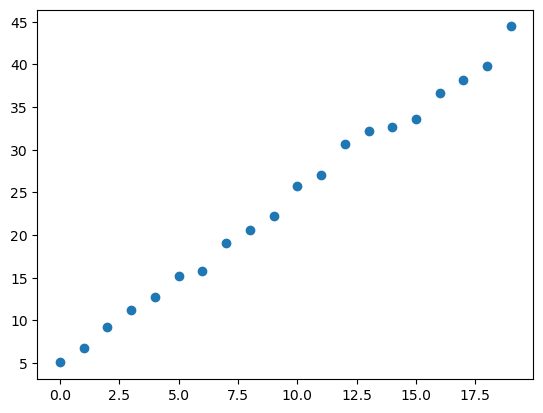

In [181]:
N_samples = 20
sigma = 1
true_data = forward_modeller([5,2], N_samples=N_samples) + np.random.normal(0, sigma, size=N_samples)

plt.plot(true_data, 'o')

# MCMC

In [182]:
theta_0 = [1,2]
modelled_data = forward_modeller(theta_0, N_samples=N_samples)
r = residual(true_data,modelled_data)
posterior_0 = 10**log_posterior(r, sigma, prior_type=log_prior_uniform)



N_iterations = 5000
delta_theta = .50
theta_chain = np.zeros((N_iterations, len(theta_0)))
theta_chain[0,:] = theta_0
for i in range(1, N_iterations):
    theta_chain[i,:] = metropolis_rule(posterior_0, theta_chain[i-1,:], delta_theta, true_data, sigma)

theta_1_mean = np.mean(theta_chain[:,0])
theta_2_mean = np.mean(theta_chain[:,1])

theta_1_std = np.std(theta_chain[:,0])
theta_2_std = np.std(theta_chain[:,1])

print(f"Estimated Theta 1: {theta_1_mean:.2f}, Estimated Theta 2: {theta_2_mean:.2f}")
print(f"Uncertainty Theta 1: {theta_1_std:.2f}, Uncertainty Theta 2: {theta_2_std:.2f}")

Estimated Theta 1: 5.68, Estimated Theta 2: 1.94
Uncertainty Theta 1: 2.98, Uncertainty Theta 2: 0.30


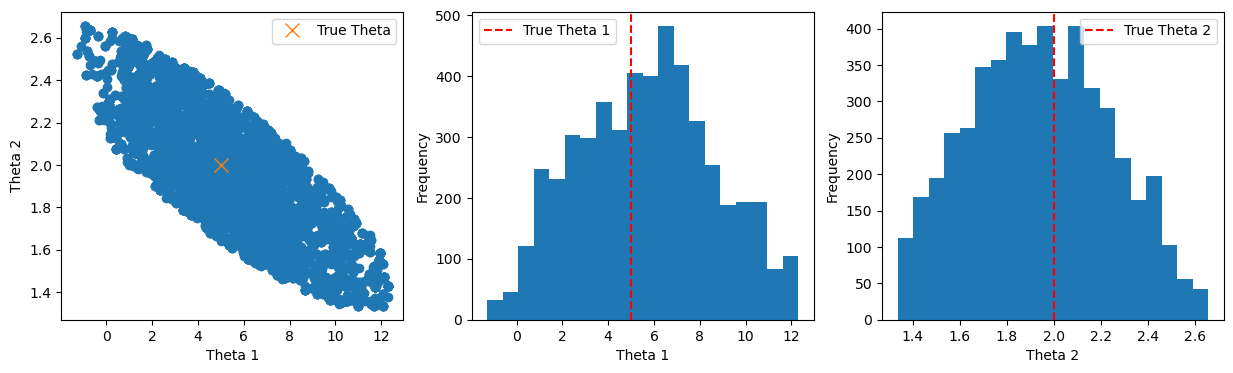

In [183]:
# subplots in a row
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

ax1.plot(theta_chain[:,0], theta_chain[:,1], 'o')
ax1.plot(5, 2, 'x', markersize=10, label='True Theta')
ax1.set_xlabel('Theta 1')
ax1.set_ylabel('Theta 2')
ax1.legend()

ax2.hist(theta_chain[:,0], bins=20)
ax2.axvline(5, color='r', linestyle='--', label='True Theta 1')
ax2.set_xlabel('Theta 1')
ax2.set_ylabel('Frequency')
ax2.legend()

ax3.hist(theta_chain[:,1], bins=20)
ax3.axvline(2, color='r', linestyle='--', label='True Theta 2')
ax3.set_xlabel('Theta 2')
ax3.set_ylabel('Frequency')
ax3.legend()
plt.show()

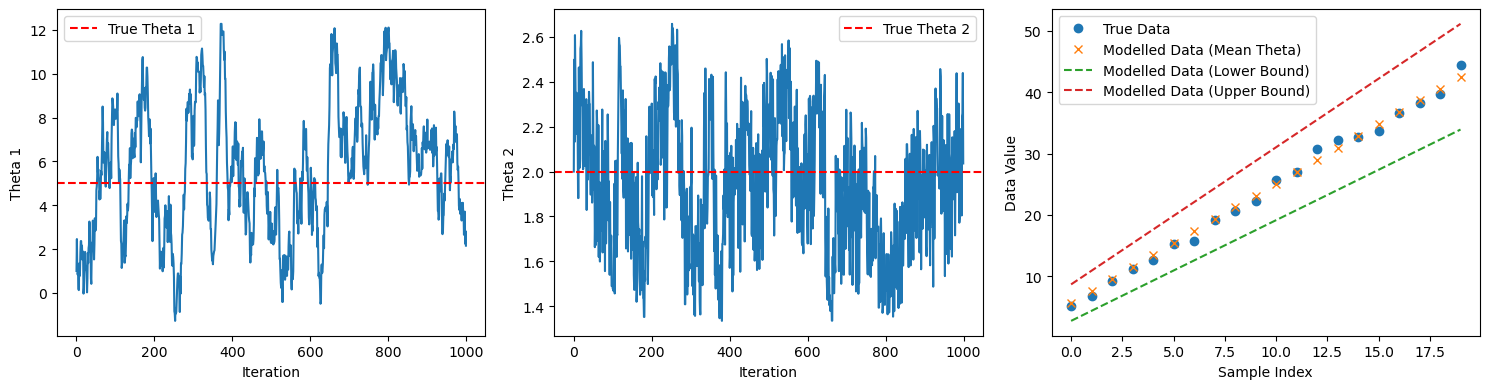

In [184]:
# subplots in a row
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

ax1.plot(theta_chain[::5,0], '-')
ax1.axhline(5, color='r', linestyle='--', label='True Theta 1')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Theta 1')
ax1.legend()
ax2.plot(theta_chain[::5,1], '-')
ax2.axhline(2, color='r', linestyle='--', label='True Theta 2')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Theta 2')
ax2.legend()

# forward modelled data with mean theta and uncertainty bounds
modelled_data_mean_theta = forward_modeller([theta_1_mean, theta_2_mean], N_samples=N_samples)
modelled_data_lower_bound = forward_modeller([theta_1_mean - theta_1_std, theta_2_mean - theta_2_std], N_samples=N_samples)
modelled_data_upper_bound = forward_modeller([theta_1_mean + theta_1_std, theta_2_mean + theta_2_std], N_samples=N_samples)
ax3.plot(true_data, 'o', label='True Data')
ax3.plot(modelled_data_mean_theta, 'x', label='Modelled Data (Mean Theta)')
ax3.plot(modelled_data_lower_bound, '--', label='Modelled Data (Lower Bound)')
ax3.plot(modelled_data_upper_bound, '--', label='Modelled Data (Upper Bound)')
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Data Value')
ax3.legend()
plt.tight_layout()
plt.show()

# EMCEE

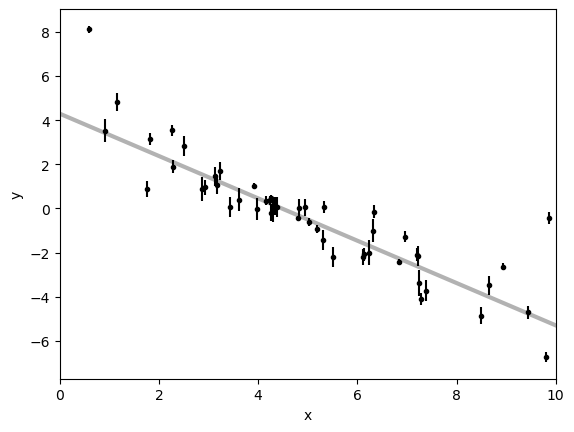

In [185]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

Least-squares estimates:
m = -1.104 ± 0.016
b = 5.441 ± 0.091


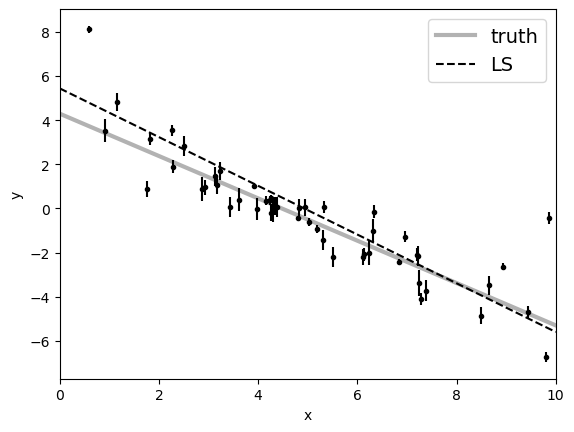

In [186]:
A = np.vander(x, 2)
C = np.diag(yerr * yerr)
ATA = np.dot(A.T, A / (yerr**2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr**2))
print("Least-squares estimates:")
print("m = {0:.3f} ± {1:.3f}".format(w[0], np.sqrt(cov[0, 0])))
print("b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [187]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

Maximum likelihood estimates:
m = -1.003
b = 4.528
f = 0.454


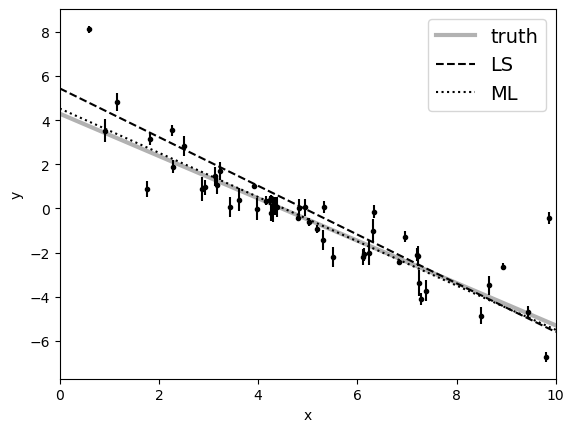

In [188]:
from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [189]:
def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

In [190]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [191]:
import emcee

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:03<00:00, 1351.05it/s]


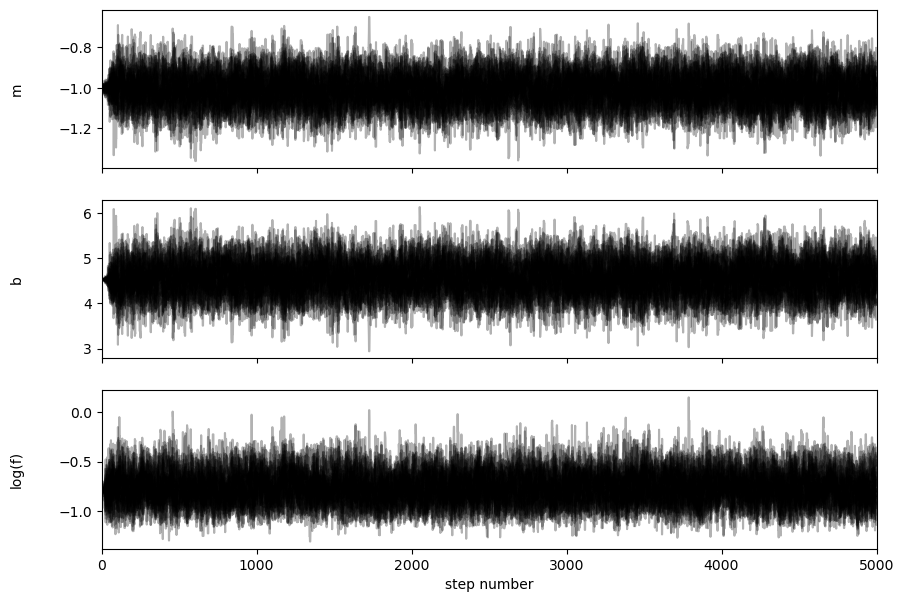

In [192]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [193]:
tau = sampler.get_autocorr_time()
print(tau)

[34.35179797 33.78964643 36.77512185]


In [194]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 3)


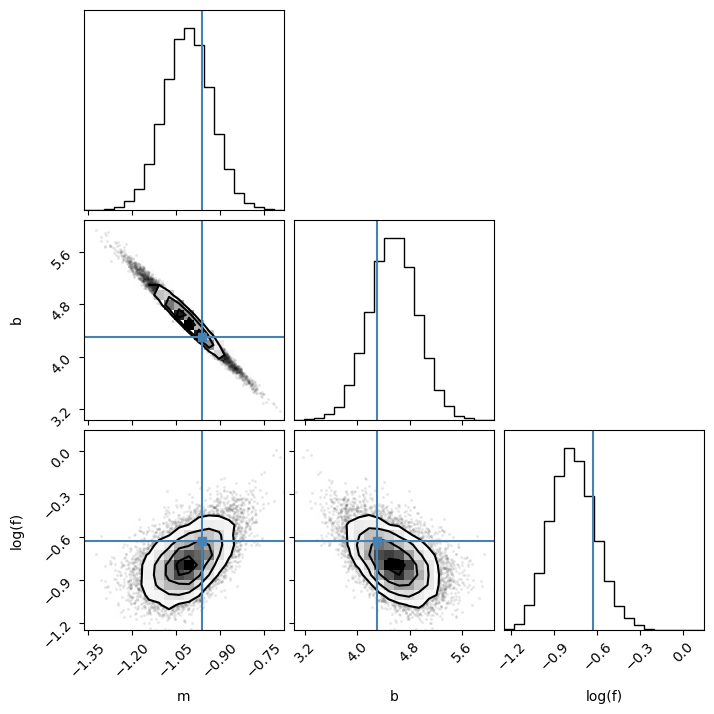

In [195]:
import corner

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
);

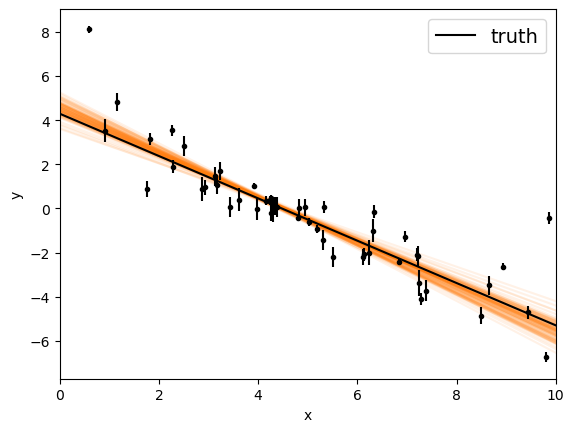

In [196]:
inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", label="truth")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [197]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6740\1529384300.py:6: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>